# 🌦️ Cambodia Weather Forecast Analysis
### Fundamentals of Data Science Project
Cambodia Academy of Digital Technology (Group 4)

This notebook analyzes weather trends in Cambodia using government open data to explore climate patterns and forecasting insights.

In [1]:
# import Library
import sys
from pathlib import Path
from datetime import datetime, timedelta
import time

import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / 'notebooks' / '_shared' / 'notebook_utils.py').exists():
    project_root = project_root.parent

shared_dir = project_root / 'notebooks' / '_shared'
if str(shared_dir) not in sys.path:
    sys.path.append(str(shared_dir))

from notebook_utils import add_time_features, eda_summary_table, load_weather_csv, missing_values_report

# plot style for cleaner visuals
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Fetch Weather Data
Collect real-time weather data from Cambodia government API for analysis of temperature, humidity, and climate trends.

In [2]:
# Provinces and coordinates
locations = [
    ("Phnom Penh", 11.55, 104.91),
    ("Siem Reap", 13.36, 103.85),
    ("Battambang", 13.10, 103.20),
    ("Sihanoukville", 10.62, 103.52),
    ("Mondulkiri", 12.45, 107.20),
]

# Request configuration
url = "https://archive-api.open-meteo.com/v1/archive"
start_date = "2015-01-01"
end_date = (datetime.now() - timedelta(days=2)).strftime("%Y-%m-%d") # safe API

all_data = [] 

for province, lat, lon in locations:
    print(f"Fetching data for {province}...")

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "wind_speed_10m_max",
        ],
        "timezone": "Asia/Bangkok",
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()

        province_df = pd.DataFrame(payload["daily"])
        province_df["province"] = province
        province_df["lat"] = lat
        province_df["lon"] = lon
        all_data.append(province_df)

        time.sleep(0.8)  # Respectful delay between requests

    except Exception as err:
        print(f"Skipped {province} due to error: {err}")

if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df = final_df.rename(
        columns={
            "time": "date",
            "temperature_2m_max": "temp_max",
            "temperature_2m_min": "temp_min",
            "precipitation_sum": "rain",
            "wind_speed_10m_max": "wind_speed",
        }
    )

    output_path = "../data/cambodia_weather.csv"
    final_df.to_csv(output_path, index=False)
    print(f"Saved {len(final_df):,} rows to {output_path}")
else:
    final_df = pd.DataFrame()
    print("No data retrieved from API.")

Fetching data for Phnom Penh...
Fetching data for Siem Reap...
Fetching data for Battambang...
Fetching data for Sihanoukville...
Fetching data for Mondulkiri...
Saved 20,570 rows to ../data/cambodia_weather.csv


### 2. Exploratory Data Analysis (Step-by-Step)
This section is organized for clear understanding of the dataset before deeper analysis:
1. Load the dataset for EDA.
2. Check total rows and columns.
3. Inspect column names and data types.
4. Validate missing values and date coverage.
5. Continue with statistics and visualization.

In [3]:
# Load dataset
try:
    df = load_weather_csv("../data/cambodia_weather.csv")
    print("Dataset loaded from ../data/cambodia_weather.csv")
except FileNotFoundError:
    df = final_df.copy()
    if not df.empty:
        df.columns = [col.strip() for col in df.columns]
    print("CSV not found, using in-memory final_df instead")

# rows and columns
rows, cols = df.shape
print(f"Total rows: {rows:,}")
print(f"Total columns: {cols}")

df.head()

Dataset loaded from ../data/cambodia_weather.csv
Total rows: 20,570
Total columns: 8


,date,temp_max,temp_min,rain,wind_speed,province,lat,lon
0,2015-01-01,30.1,20.5,0.0,20.0,Phnom Penh,11.55,104.91
1,2015-01-02,30.0,19.9,0.0,18.7,Phnom Penh,11.55,104.91
2,2015-01-03,31.2,22.6,0.0,16.9,Phnom Penh,11.55,104.91
3,2015-01-04,31.5,22.2,0.0,9.4,Phnom Penh,11.55,104.91
4,2015-01-05,32.2,23.6,0.0,9.7,Phnom Penh,11.55,104.91


In [4]:
# Display dataframe shape and summary info
print("=" * 60)
print("DATAFRAME SUMMARY")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nDataFrame Info:")
df.info()
print(f"\nData Types:\n{df.dtypes}")
print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")
print(f"\nUnique Provinces: {df['province'].nunique()} ({', '.join(df['province'].unique())})")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nLast 5 rows:")
display(df.tail())

DATAFRAME SUMMARY

Shape: 20,570 rows × 8 columns

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20570 entries, 0 to 20569
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        20570 non-null  object 
 1   temp_max    20570 non-null  float64
 2   temp_min    20570 non-null  float64
 3   rain        20570 non-null  float64
 4   wind_speed  20570 non-null  float64
 5   province    20570 non-null  object 
 6   lat         20570 non-null  float64
 7   lon         20570 non-null  float64
dtypes: float64(6), object(2)
memory usage: 1.3+ MB

Data Types:
date           object
temp_max      float64
temp_min      float64
rain          float64
wind_speed    float64
province       object
lat           float64
lon           float64
dtype: object

Date Range: 2015-01-01 to 2026-04-06

Unique Provinces: 5 (Phnom Penh, Siem Reap, Battambang, Sihanoukville, Mondulkiri)

First 5 rows:


,date,temp_max,temp_min,rain,wind_speed,province,lat,lon
0,2015-01-01,30.1,20.5,0.0,20.0,Phnom Penh,11.55,104.91
1,2015-01-02,30.0,19.9,0.0,18.7,Phnom Penh,11.55,104.91
2,2015-01-03,31.2,22.6,0.0,16.9,Phnom Penh,11.55,104.91
3,2015-01-04,31.5,22.2,0.0,9.4,Phnom Penh,11.55,104.91
4,2015-01-05,32.2,23.6,0.0,9.7,Phnom Penh,11.55,104.91



Last 5 rows:


,date,temp_max,temp_min,rain,wind_speed,province,lat,lon
20565,2026-04-02,32.5,19.4,0.0,12.7,Mondulkiri,12.45,107.2
20566,2026-04-03,32.0,18.1,0.0,20.9,Mondulkiri,12.45,107.2
20567,2026-04-04,32.0,20.1,0.0,19.5,Mondulkiri,12.45,107.2
20568,2026-04-05,32.5,20.5,0.0,18.5,Mondulkiri,12.45,107.2
20569,2026-04-06,32.3,20.5,0.0,20.8,Mondulkiri,12.45,107.2


### Step 3. Inspect Columns and Data Types
Now we check what each column represents and confirm data types before cleaning.

In [5]:
# Column list and data types
print("Columns in dataset:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

# Convert and prepare key fields for analysis
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "temp_max", "temp_min", "rain", "wind_speed", "province"])
df = df.drop_duplicates().sort_values(["province", "date"]).reset_index(drop=True)
df = add_time_features(df, date_col="date")
df["temp_avg"] = (df["temp_max"] + df["temp_min"]) / 2

print(f"\nShape after preparation: {df.shape}")

Columns in dataset:
1. date
2. temp_max
3. temp_min
4. rain
5. wind_speed
6. province
7. lat
8. lon

Data types:


,dtype
date,object
temp_max,float64
temp_min,float64
rain,float64
wind_speed,float64
province,object
lat,float64
lon,float64



Shape after preparation: (20570, 17)


In [6]:
# Statistical summary of numeric columns
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(f"\nDescriptive Statistics:\n")
display(df[["temp_max", "temp_min", "rain", "wind_speed"]].describe().round(2))

STATISTICAL SUMMARY

Descriptive Statistics:



,temp_max,temp_min,rain,wind_speed
count,20570.00,20570.00,20570.00,20570.00
mean,30.84,23.59,5.23,15.26
std,3.04,2.59,8.39,5.27
min,18.20,11.40,0.00,3.80
25%,28.90,21.90,0.00,11.50
50%,30.90,24.40,1.70,14.40
75%,32.70,25.40,7.10,18.00
max,42.20,30.20,143.90,45.90


In [7]:
# Data quality checks - missing values and duplicates
print("=" * 60)
print("DATA QUALITY METRICS")
print("=" * 60)
print(f"\nMissing Values:\n")
quality_df = missing_values_report(df)
display(quality_df[quality_df["Missing Count"] > 0] if quality_df["Missing Count"].sum() > 0 else "No missing values!")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nData is clean and ready for analysis!")

DATA QUALITY METRICS

Missing Values:



'No missing values!'


Duplicate Rows: 0

Data is clean and ready for analysis!


### Step 4. Data Quality Check
After type conversion and cleaning, verify missing values and date coverage.

In [8]:
# Missing-value report
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False))

# Date coverage check
print("\nDate coverage:")
print(f"Start date: {df['date'].min().date()}")
print(f"End date:   {df['date'].max().date()}")

# Province-level descriptive statistics
summary_stats = (
    df.groupby("province")[["temp_max", "temp_min", "temp_avg", "rain", "wind_speed"]]
    .agg(["mean", "median", "std"])
    .round(2)
)
summary_stats

Missing values by column:


date             0
temp_max         0
temp_min         0
rain             0
wind_speed       0
province         0
lat              0
lon              0
year             0
month            0
day              0
dayofweek        0
month_sin        0
month_cos        0
dayofweek_sin    0
dayofweek_cos    0
temp_avg         0
dtype: int64


Date coverage:
Start date: 2015-01-01
End date:   2026-04-06


temp_max              temp_min              temp_avg         \
                  mean median   std     mean median   std     mean median   
province                                                                    
Battambang       32.76   32.6  2.84    24.26   24.6  2.15    28.51  28.50   
Mondulkiri       27.43   27.1  2.53    19.92   20.5  1.88    23.67  23.70   
Phnom Penh       32.18   32.0  2.18    24.71   24.9  1.47    28.45  28.35   
Siem Reap        31.96   31.8  2.35    24.12   24.5  2.18    28.04  28.00   
Sihanoukville    29.85   29.9  1.49    24.94   24.9  1.12    27.40  27.40   

                     rain               wind_speed               
                std  mean median    std       mean median   std  
province                                                         
Battambang     2.26  3.72    1.0   6.37      14.77   14.3  4.35  
Mondulkiri     1.76  4.66    1.5   8.04      19.13   18.1  7.08  
Phnom Penh     1.61  4.64    1.4   7.22      14.81   14.5  4.03  
Siem Reap      2.03  4.59    1.1   7.47      13.38   13.0  3.72  
Sihanoukville  1.05  8.54    4.1  11.15      14.17   13.6  4.44

### Step 4. Visual Analysis
We use visual EDA to understand variability and trends:
- Temperature spread across provinces.
- Monthly rainfall pattern.
- Yearly temperature trend by province.

C:\Users\ROG\AppData\Local\Temp\ipykernel_29080\3958132997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="province", y="temp_avg", palette="Set2")


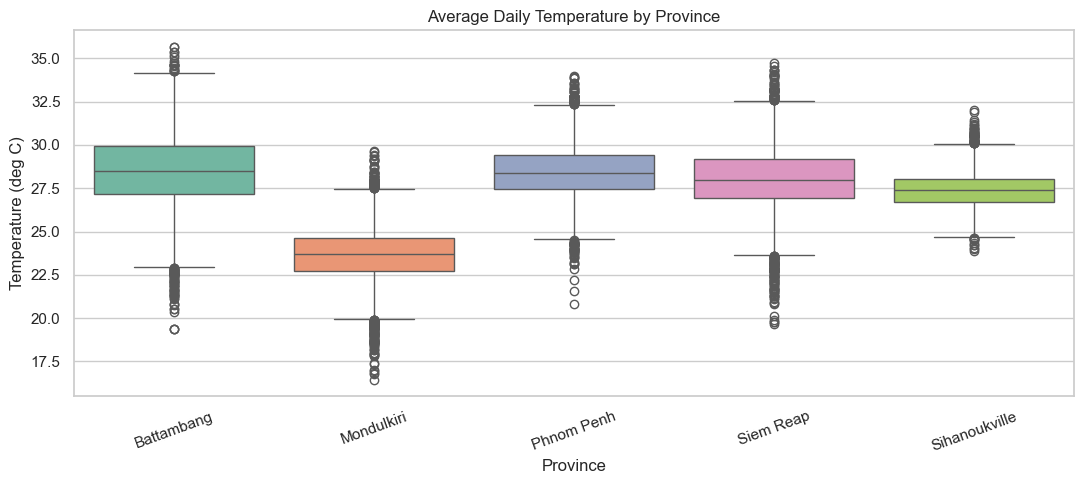

In [9]:
# Temperature distribution by province
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="province", y="temp_avg", palette="Set2")
plt.title("Average Daily Temperature by Province")
plt.xlabel("Province")
plt.ylabel("Temperature (deg C)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Step 5. Temporal Trends
We now evaluate weather behavior over time to reveal seasonal and long-term signals useful for forecasting.

#### 5.1 Monthly Rainfall Trend (All Provinces Combined)

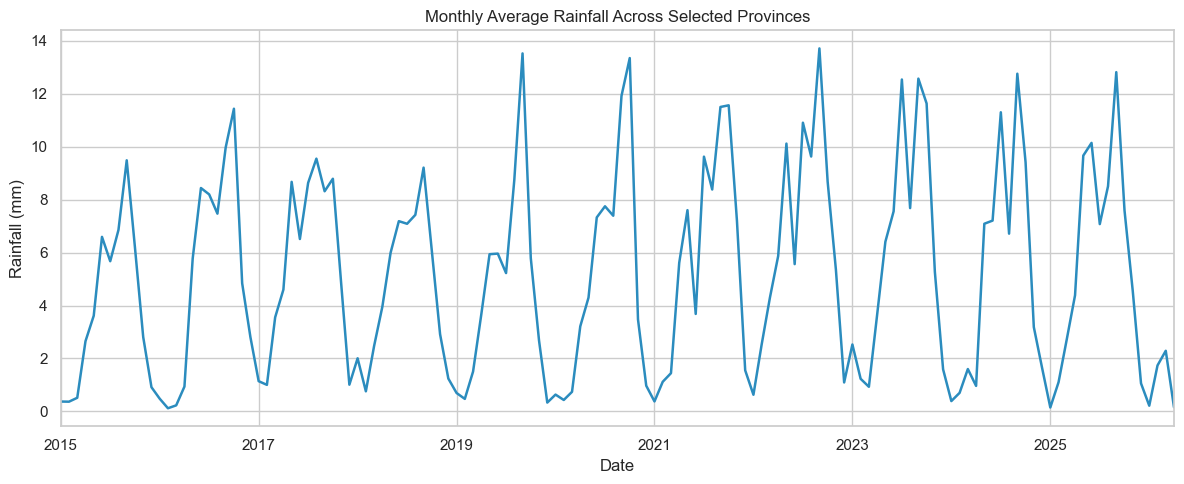

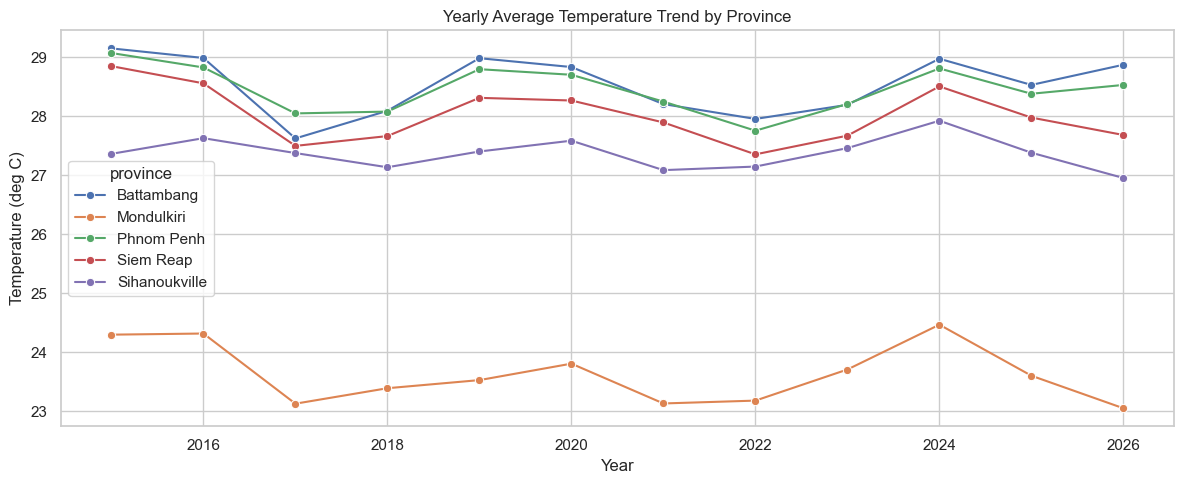

In [10]:
# Monthly rainfall trend
monthly_rain = df.set_index("date").resample("ME")["rain"].mean()

plt.figure(figsize=(12, 5))
monthly_rain.plot(color="#2b8cbe", linewidth=1.8)
plt.title("Monthly Average Rainfall Across Selected Provinces")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

# Yearly average temperature trend by province
yearly_temp = (
    df.groupby(["year", "province"])["temp_avg"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_temp, x="year", y="temp_avg", hue="province", marker="o")
plt.title("Yearly Average Temperature Trend by Province")
plt.xlabel("Year")
plt.ylabel("Temperature (deg C)")
plt.tight_layout()
plt.show()

In [11]:
# latest province snapshot for quick comparison
latest_snapshot = (
    df.sort_values("date")
    .groupby("province")
    .tail(1)
    [["province", "date", "temp_max", "temp_min", "temp_avg", "rain", "wind_speed"]]
    .reset_index(drop=True)
)
latest_snapshot

,province,date,temp_max,temp_min,temp_avg,rain,wind_speed
0,Siem Reap,2026-04-06,36.0,26.4,31.20,0.0,13.2
1,Mondulkiri,2026-04-06,32.3,20.5,26.40,0.0,20.8
2,Battambang,2026-04-06,38.9,27.5,33.20,0.0,20.8
3,Phnom Penh,2026-04-06,36.7,25.3,31.00,0.0,17.2
4,Sihanoukville,2026-04-06,31.4,26.3,28.85,0.0,15.1


### 5.2 Feature Relationship Visualization
To better understand forecasting signals, we visualize numeric feature correlations and monthly temperature seasonality.

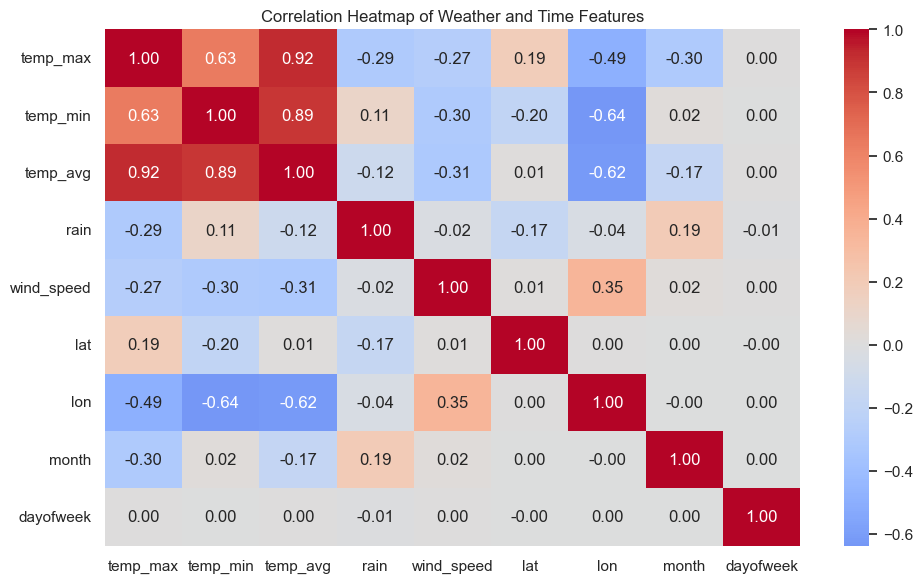

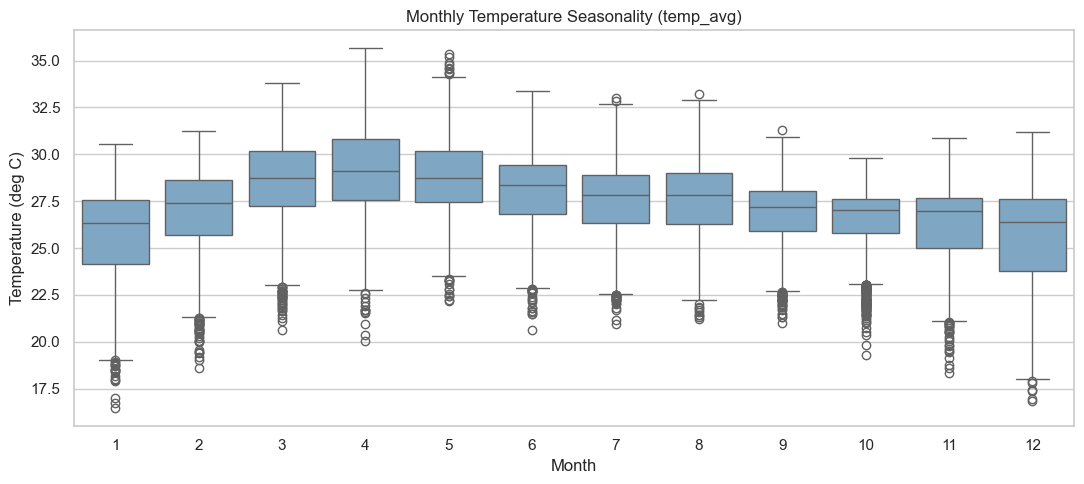

In [12]:
# Correlation heatmap for key numeric features
corr_cols = ['temp_max', 'temp_min', 'temp_avg', 'rain', 'wind_speed', 'lat', 'lon', 'month', 'dayofweek']
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Weather and Time Features')
plt.tight_layout()
plt.show()

# Monthly seasonality of average temperature
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='month', y='temp_avg', color='#74a9cf')
plt.title('Monthly Temperature Seasonality (temp_avg)')
plt.xlabel('Month')
plt.ylabel('Temperature (deg C)')
plt.tight_layout()
plt.show()

### 6. EDA Summary

This section generates a concise, report-ready summary of:
- EDA key facts (rows, date range, provinces, data quality)
- Climate statistics (temperature, rainfall, wind)
- Data completeness and readiness for downstream modeling


In [15]:
# Report-ready EDA summary
if "df" not in globals():
    df = load_weather_csv("../data/cambodia_weather.csv")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date", "temp_max", "temp_min", "rain", "wind_speed", "province"])
    df = df.drop_duplicates().sort_values(["province", "date"]).reset_index(drop=True)
    df = add_time_features(df, date_col="date")
    df["temp_avg"] = (df["temp_max"] + df["temp_min"]) / 2

eda_summary_df = eda_summary_table(df)

print("EDA SUMMARY")
display(eda_summary_df)

EDA SUMMARY


EDA SUMMARY


,Metric,Value
0,Rows,"20,570"
1,Columns,17
2,Date start,2015-01-01
3,Date end,2026-04-06
4,Provinces,"Battambang, Mondulkiri, Phnom Penh, Siem Reap,..."
5,Missing values,0
6,Duplicate rows,0
7,Mean temp_max (C),30.84
8,Mean temp_min (C),23.59
9,Mean temp_avg (C),27.21



MODEL TEST PERFORMANCE (PERCENTAGE INCLUDED)


,Target,R2,Test Accuracy (%),Accuracy Label,MAE,RMSE,Train Rows,Test Rows
0,temp_max,0.862460,86.25,86.25%,0.847500,1.120510,16448,4112
1,temp_min,0.861958,86.20,86.20%,0.762408,0.999003,16448,4112



Best model by R2: temp_max | R2=0.8625 | Test Accuracy=86.25%
